In [1]:
import matplotlib.pyplot as plt

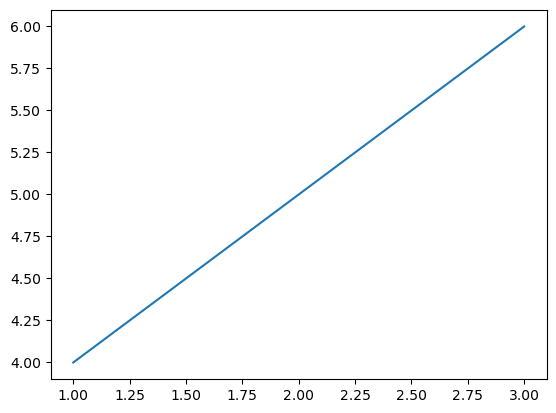

In [3]:
plt.plot([1,2,3],[4,5,6])

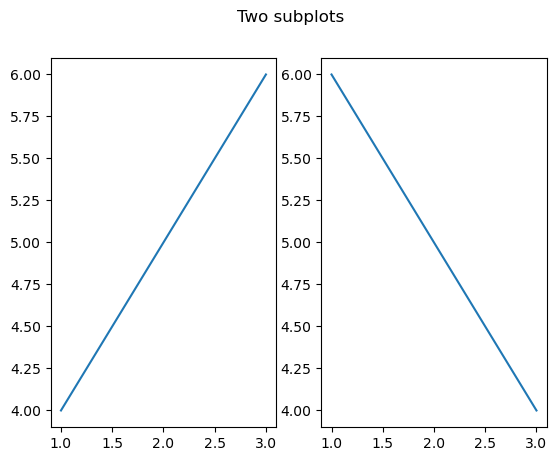

In [4]:
fig, axes = plt.subplots(1, 2)
fig.suptitle('Two subplots')
figsize = (10, 5)
axes[0].plot([1, 2, 3], [4, 5, 6])
axes[1].plot([1, 2, 3], [6, 5, 4])

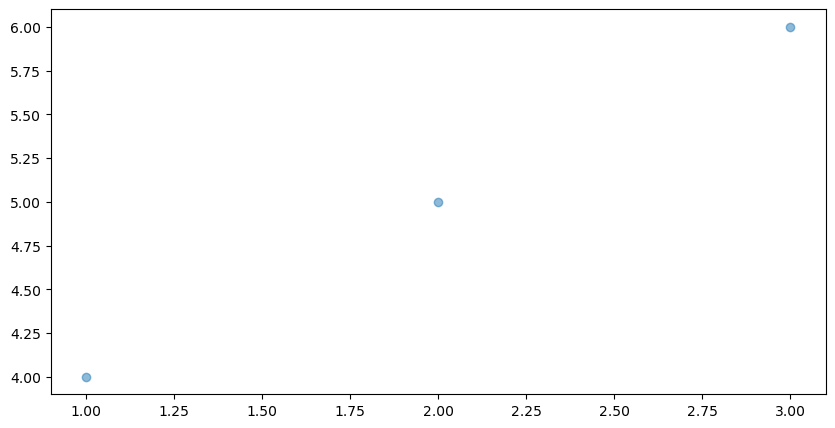

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter([1, 2, 3], [4, 5, 6], alpha=0.5)

<BarContainer object of 3 artists>

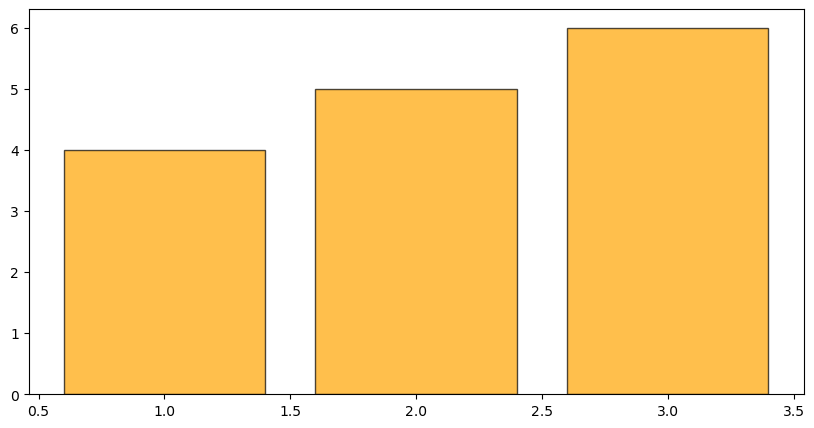

In [11]:
ig, ax = plt.subplots(figsize=(10, 5))
ax.bar([1, 2, 3], [4, 5, 6], color='orange', alpha=0.7, edgecolor='black')

In [9]:
plt.show()

(array([2., 2., 2.]),
 array([1.        , 2.66666667, 4.33333333, 6.        ]),
 <BarContainer object of 3 artists>)

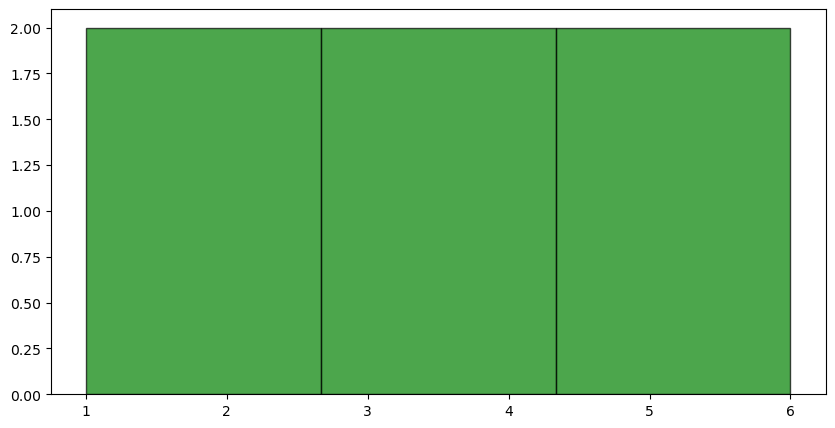

In [12]:
fig,ax = plt.subplots(figsize=(10, 5))
ax.hist([1, 2, 3, 4, 5, 6], bins=3, color='green', alpha=0.7, edgecolor='black')

Text(0.5, 1.0, 'Boxplot Example')

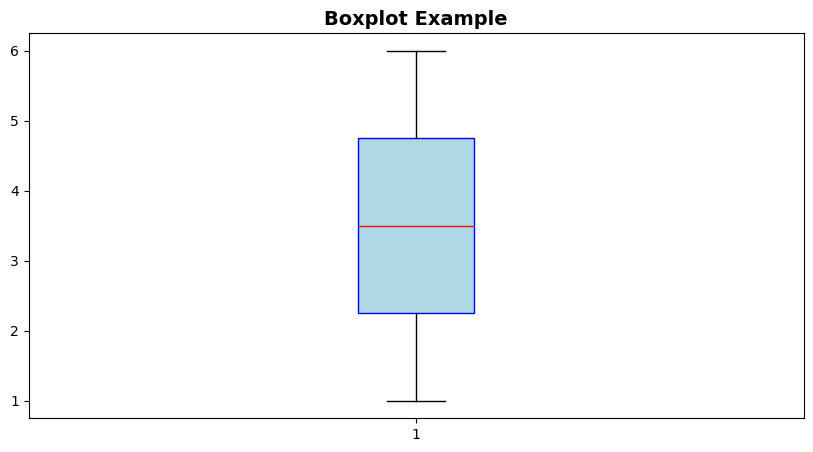

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.boxplot([1, 2, 3, 4, 5, 6], patch_artist=True, boxprops=dict(facecolor='lightblue', color='blue'), medianprops=dict(color='red'))
ax.set_title('Boxplot Example',fontsize=14,fontweight='bold' )

In [15]:
import seaborn as sns


In [16]:
sns.set_theme(style="whitegrid")


In [17]:
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (10, 5)

<Axes: ylabel='Count'>

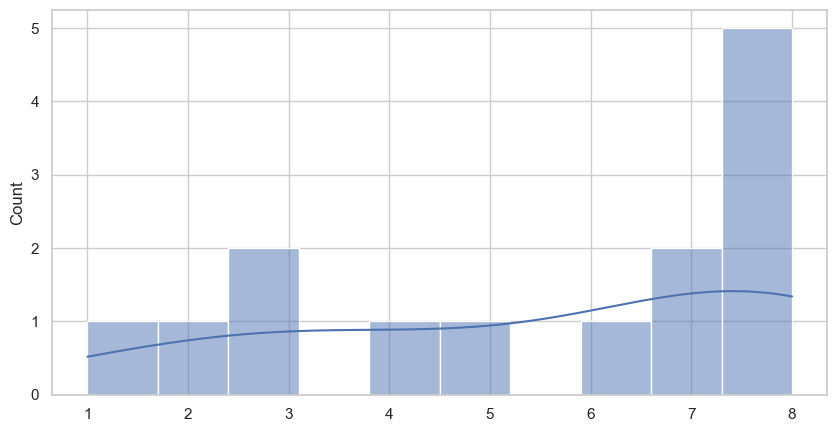

In [18]:
sns.histplot([1,2,3,3,4,5,6,7,7,8,8,8,8,8], bins =10, kde =True)

<Axes: ylabel='Density'>

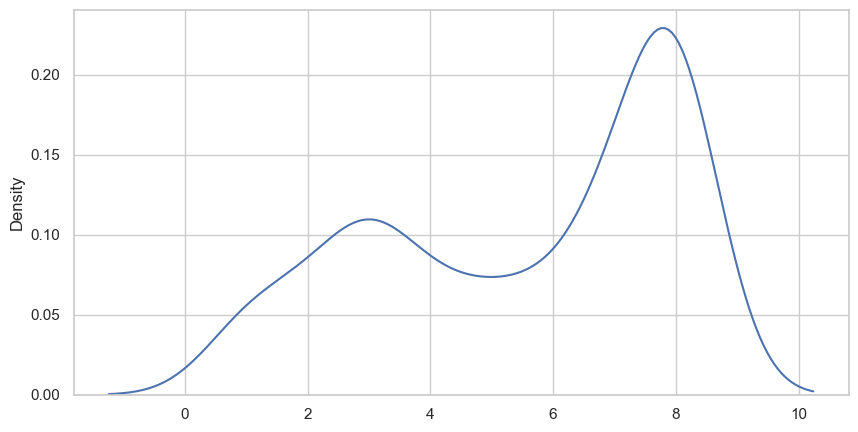

In [19]:
sns.kdeplot([1,2,3,3,4,5,6,7,7,8,8,8,8,8], bw_adjust=0.5)   

<Axes: >

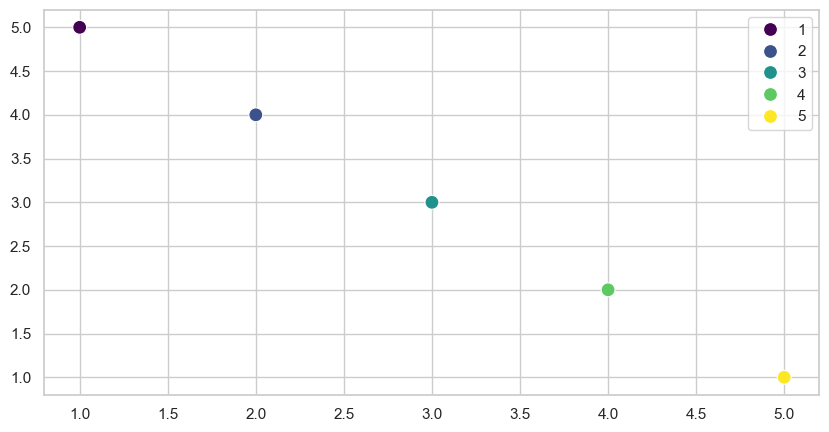

In [21]:
sns.scatterplot(x=[1, 2, 3, 4, 5], y=[5, 4, 3, 2, 1], hue=[1, 2, 3, 4, 5], palette='viridis', s=100)

<Axes: >

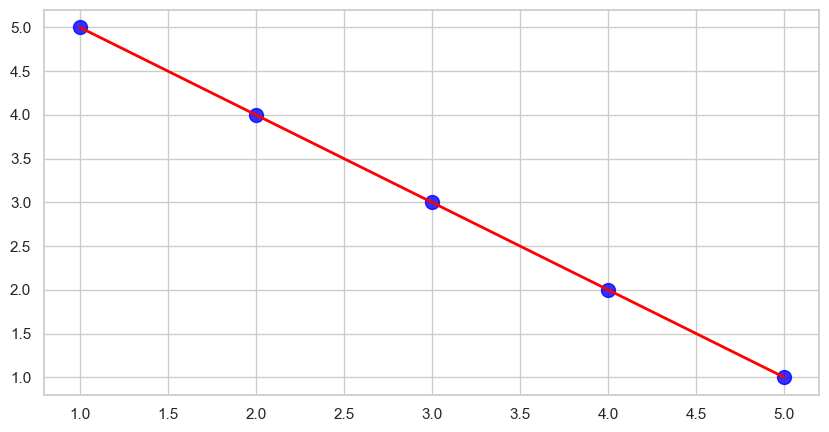

In [22]:
sns.regplot(x=[1, 2, 3, 4, 5], y=[5, 4, 3, 2, 1], color='blue', marker='o', scatter_kws={'s':100}, line_kws={'color':'red', 'linewidth':2})

<Axes: >

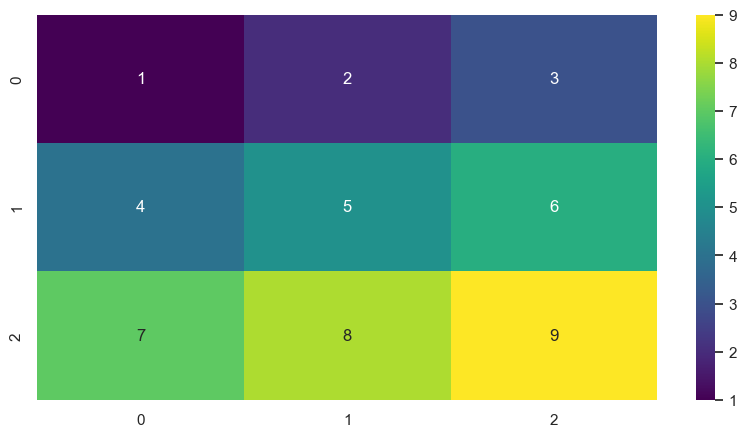

In [23]:
sns.heatmap(data=[[1, 2, 3], [4, 5, 6], [7, 8, 9]], cmap='viridis', annot=True)

<Axes: >

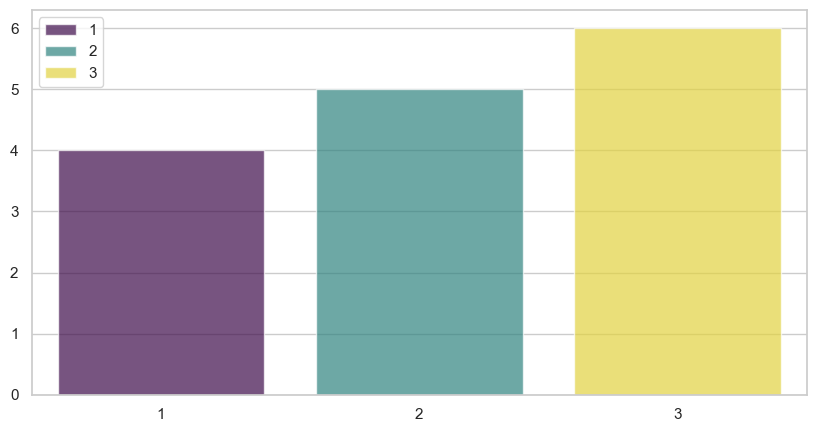

In [25]:
sns.barplot(x=[1, 2, 3], y=[4, 5, 6], palette='viridis', alpha=0.7,hue=[1, 2, 3], dodge=False)

<Axes: >

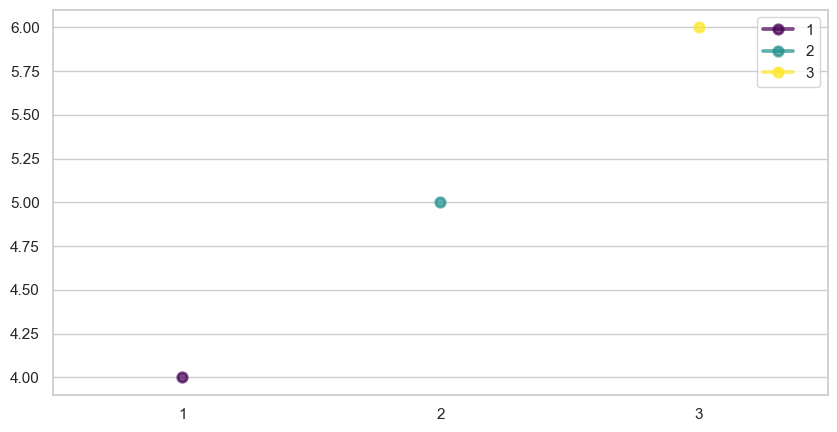

In [26]:
sns.pointplot(x=[1, 2, 3], y=[4, 5, 6], palette='viridis', alpha=0.7,hue=[1, 2, 3], dodge=False)

<Axes: >

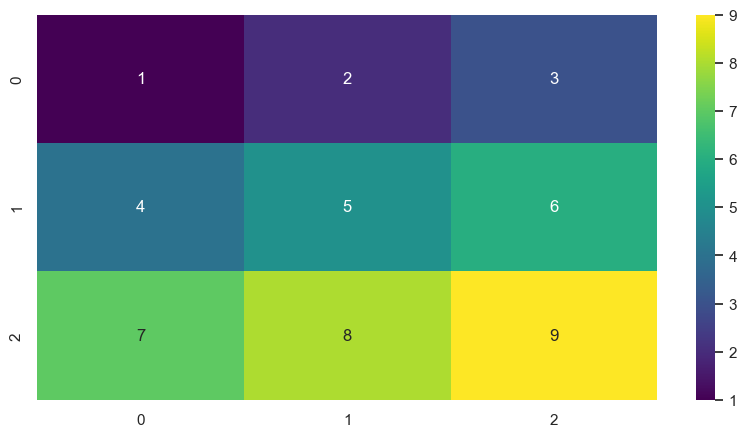

In [27]:
sns.heatmap(data=[[1, 2, 3], [4, 5, 6], [7, 8, 9]], cmap='viridis', annot=True)

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer


In [30]:
df = pd.read_csv('Datasets/Titanic/Titanic.csv')

In [31]:
df.head()


,Unnamed: 0,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [32]:
df = df[['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'survived']]

In [33]:
df.shape

(891, 8)

In [34]:
df.isnull().sum()

pclass        0
sex           0
age         177
sibsp         0
parch         0
fare          0
embarked      2
survived      0
dtype: int64

In [35]:
df.dtypes

pclass        int64
sex          object
age         float64
sibsp         int64
parch         int64
fare        float64
embarked     object
survived      int64
dtype: object

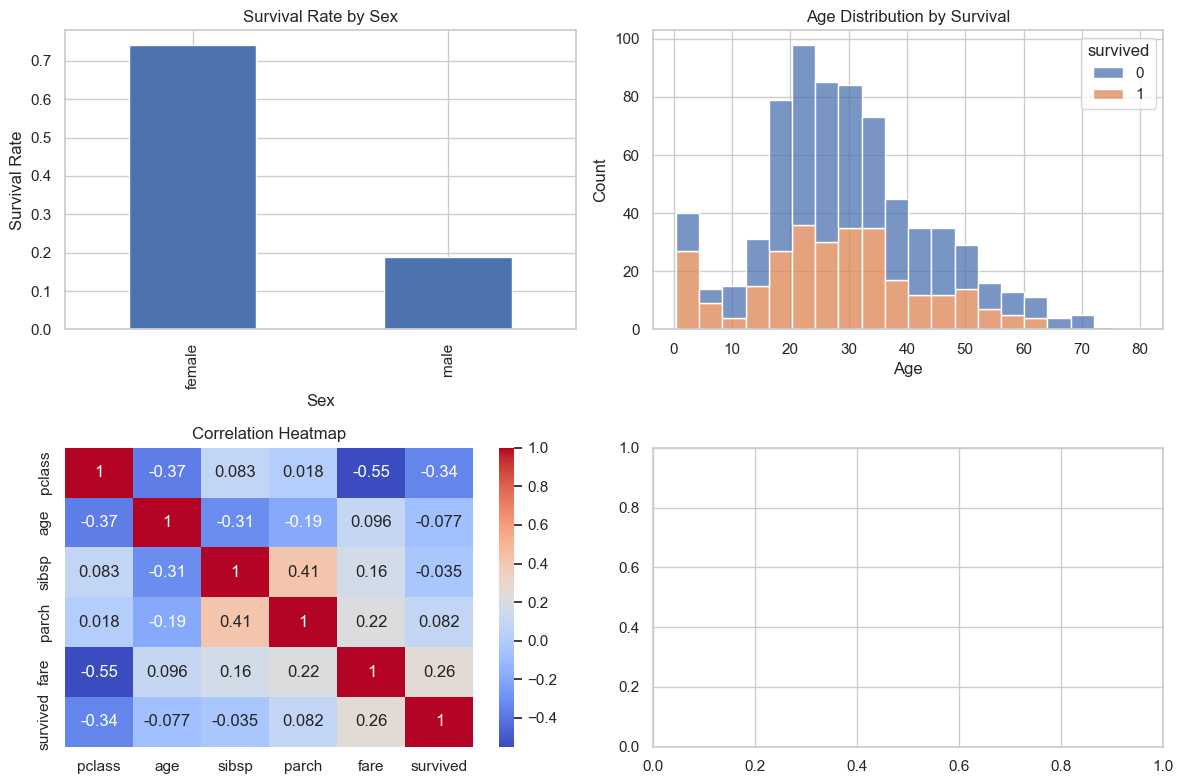

In [38]:
sns.set_theme(style="whitegrid")
fig,axes = plt.subplots(2,2,figsize=(12,8))
df.groupby('sex')['survived'].mean().plot(kind='bar',ax=axes[0,0],title='Survival Rate by Sex')
axes[0,0].set_ylabel('Survival Rate')
axes[0,0].set_xlabel('Sex')
axes[0,0].set_title('Survival Rate by Sex')

sns.histplot(data=df,x='age',hue='survived',multiple='stack',ax=axes[0,1])
axes[0,1].set_title('Age Distribution by Survival') 
axes[0,1].set_xlabel('Age')
axes[0,1].set_ylabel('Count')

corr = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr,annot=True,cmap='coolwarm',ax=axes[1,0])
axes[1,0].set_title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [39]:
df['family_size'] = df['sibsp'] + df['parch']+1


In [40]:
df['family_size']

0      2
1      2
2      1
3      2
4      1
      ..
886    1
887    1
888    4
889    1
890    1
Name: family_size, Length: 891, dtype: int64

In [41]:
df['is_alone'] = df['family_size'].apply(lambda x: 1 if x == 1 else 0)

In [42]:
df['is_alone']

0      0
1      0
2      1
3      0
4      1
      ..
886    1
887    1
888    0
889    1
890    1
Name: is_alone, Length: 891, dtype: int64

In [44]:
df['fare_pp']= df['fare']/(df['family_size']+1).astype(int)


In [45]:
df.head()

,pclass,sex,age,sibsp,parch,fare,embarked,survived,family_size,is_alone,fare_pp
0,3,male,22.0,1,0,7.2500,S,0,2,0,2.416667
1,1,female,38.0,1,0,71.2833,C,1,2,0,23.761100
2,3,female,26.0,0,0,7.9250,S,1,1,1,3.962500
3,1,female,35.0,1,0,53.1000,S,1,2,0,17.700000
4,3,male,35.0,0,0,8.0500,S,0,1,1,4.025000


In [46]:
df['isa_child'] = df['age'].apply(lambda x: 1 if x < 18 else 0)

In [47]:
df['log_fare'] = np.log1p(df['fare'])

In [48]:
df.head()

,pclass,sex,age,sibsp,parch,fare,embarked,survived,family_size,is_alone,fare_pp,isa_child,log_fare
0,3,male,22.0,1,0,7.2500,S,0,2,0,2.416667,0,2.110213
1,1,female,38.0,1,0,71.2833,C,1,2,0,23.761100,0,4.280593
2,3,female,26.0,0,0,7.9250,S,1,1,1,3.962500,0,2.188856
3,1,female,35.0,1,0,53.1000,S,1,2,0,17.700000,0,3.990834
4,3,male,35.0,0,0,8.0500,S,0,1,1,4.025000,0,2.202765


In [50]:
df['sex_encoded'] = (df['sex']=='female').astype(int)
df = pd.get_dummies(df, columns=['embarked'], drop_first=True,dtype= int)

In [51]:
df['age'].fillna(df['age'].median(), inplace=True)

C:\Users\hp\AppData\Local\Temp\ipykernel_22900\1654433547.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].median(), inplace=True)


In [52]:
df.drop(columns =['sex','fare','sibsp','parch'], inplace=True)

In [53]:
df.head()

,pclass,age,survived,family_size,is_alone,fare_pp,isa_child,log_fare,sex_encoded,embarked_Q,embarked_S
0,3,22.0,0,2,0,2.416667,0,2.110213,0,0,1
1,1,38.0,1,2,0,23.761100,0,4.280593,1,0,0
2,3,26.0,1,1,1,3.962500,0,2.188856,1,0,1
3,1,35.0,1,2,0,17.700000,0,3.990834,1,0,1
4,3,35.0,0,1,1,4.025000,0,2.202765,0,0,1


In [54]:
feature_cols = [c for c in df.columns if c not in ['survived']]

In [55]:
X = df[feature_cols]
y= df['survived']


In [56]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [57]:
pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),  
    ('scaler', StandardScaler()),  
    ('model', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)) ])

In [58]:
pipe.fit(X_train, y_train)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('model', RandomForestClassifier(n_jobs=-1, random_state=42))])

In [59]:
y_pred = pipe.predict(X_test)

In [60]:
y_pred 

array([0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0,
       0, 1, 1], dtype=int64)

In [61]:
y_prob = pipe.predict_proba(X_test)[:, 1]

In [62]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.85      0.85       105
           1       0.78      0.78      0.78        74

    accuracy                           0.82       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.82      0.82      0.82       179



In [63]:
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred)}")

Confusion Matrix:
[[89 16]
 [16 58]]


In [66]:
from sklearn.metrics import roc_auc_score


print(f'ROC-AUC Score: {roc_auc_score(y_test, y_prob)}')

ROC-AUC Score: 0.90006435006435


ValueError: too many values to unpack (expected 2)

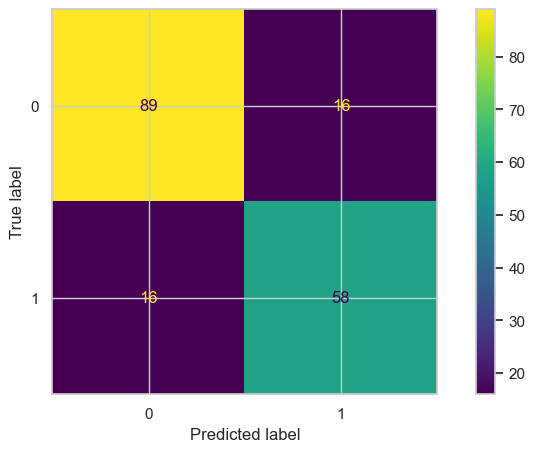

In [68]:
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve


fig, axes = plt.subplots(figsize=(10, 5))
ConfusionMatrixDisplay.from_predictions(y_pred, y_test, ax=axes)

fpr , tpr = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color='blue', label='ROC Curve')
axes[1].set_title('ROC Curve')

axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()
axes[1].plot([0,1],[0,1],'k--')

In [69]:
rf = pipe.named_steps['model']

In [70]:
rf

RandomForestClassifier(n_jobs=-1, random_state=42)

In [71]:
imp = pd.Series(rf.feature_importances_ ,index = feature_cols).sort_values(ascending=False)

In [72]:
fig, axes = plt.subplot(figsize=(2,5))
axes[1].barh(imp.index[:10],imp.values[:10],color ='corat')

AttributeError: Axes.set() got an unexpected keyword argument 'figsize'

<Figure size 1000x500 with 0 Axes>